# Demand Estimation — Part 2: Data Scientist

In this section, we estimate a logit-style demand model using linear regression. The dependent variable is log brand share, and the model includes price, rating, product characteristics, and brand and year fixed effects. The goal is to understand how these factors influence demand in the air fryer market.

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv("sample_data/air_fryers_clean_brand_year.csv")
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [4]:
df.shape
df['brand'].nunique()
df['year'].unique()

array([2019, 2020, 2021, 2022, 2023])

In [5]:
# predictors
X = df[['avg_price', 'avg_rating',
        'oven_style_share',
        'rotisserie_share',
        'window_share']]

In [6]:
# add dummies
X = pd.concat([
    X,
    pd.get_dummies(df['brand'], drop_first=True),
    pd.get_dummies(df['year'], drop_first=True)
], axis=1)

In [7]:
# outcome
y = df['log_brand_share']

# add constant
X = sm.add_constant(X)

X = X.astype(float)

# run model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_brand_share   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     4.076
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000301
Time:                        16:34:34   Log-Likelihood:                -42.141
No. Observations:                  50   AIC:                             122.3
Df Residuals:                      31   BIC:                             158.6
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -43.8633     12.294  

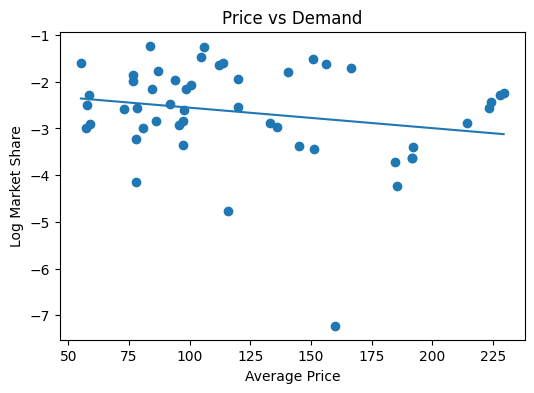

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))

# scatter plot
plt.scatter(df['avg_price'], df['log_brand_share'])

# labels + title
plt.xlabel('Average Price')
plt.ylabel('Log Market Share')
plt.title('Price vs Demand')

# trend line
z = np.polyfit(df['avg_price'], df['log_brand_share'], 1)
p = np.poly1d(z)
x_sorted = np.sort(df['avg_price'])
plt.plot(x_sorted, p(x_sorted))

plt.show()

## 1. Price Coefficient
The Estimated price coefficient is -0.0282

## 2. Is it negative? Why is that important?

Yes, the price coefficient is negative.

This is important because it aligns with standard economic theory: as price increases, demand decreases. A negative price coefficient confirms that consumers are price sensitive in the air fryer market. If the coefficient were positive, it would suggest that higher prices increase demand, which would indicate a problem with the model.

## 3. Product Features

Among the product characteristics, oven_style_share and window_share have positive coefficients, suggesting a potential association with higher demand. However, these effects are not statistically significant at conventional levels, so they should be interpreted with caution.

rotisserie_share is close to zero and highly insignificant, indicating it does not meaningfully affect demand.

Interestingly, avg_rating is positive and statistically significant, indicating that higher-rated products are associated with higher demand. This suggests that consumer reviews and perceived quality play an important role in purchasing decisions.

Overall, there is limited strong evidence that product features alone drive demand differences in this market.

## 4. Brand Effects

The largest brand dummy coefficients are:
- cusinart (4.8636)
- oster (3.2082)
- nuwave (3.1988)
- ninja (2.6546)

These positive coefficients suggest that these brands may have higher demand relative to the omitted baseline brand, holding price and product characteristics constant. This indicates potential brand value or consumer preference beyond observable features.

However, most of these coefficients are not statistically significant at conventional levels, so these differences should be interpreted with caution.

## 5. Year Effects

The year dummy coefficients are all slightly negative:
- 2020: -0.0125
- 2021: -0.0497
- 2022: -0.1263
- 2023: -0.1774

This suggests that (relative to baseline year of 2019) demand within this cleaned brand set has slightly decreased over time. However, these effects are small and not statistically significant, indicating that the market is relatively stable over time.

## 6. Model Fit (R^2)
The model has an R^2 of approximately 0.70, meaning the model explains about 70% of the variation in log market share, which indicates a strong fit for this type of demand estimation model.

## Conclusion

Overall, the model suggests that demand in the air fryer market is primarily driven by price and consumer ratings, while product features play a more limited role. Brand identity also appears to influence demand, although these effects are not always statistically significant.